# A simple script showing how to access the data

In [11]:
# Loading packages
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, join
from scipy.optimize import least_squares

In [2]:
! pip install pyneb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.7/28.7 MB 25.0 MB/s eta 0:00:00


In [3]:
import pyneb as pn

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Reading in the catalog with the redshift information
catalog = Table.read('./drive/MyDrive/MPhysProject2025/data/excels_cat_internal_v2_0p5asec_120424_miri.fits')

In [ ]:
# Selecting the redshift of target 40081
z_spec = catalog[catalog['targetid']==40081]['z_excels_v1'][0]

In [ ]:
# Loading the spectrum of target 40081
spectrum = np.loadtxt('./drive/MyDrive/MPhysProject2025/data/spec1d_fluxcal/spec1d_40081_g395m_final.txt')

In [ ]:
# Plotting the spectrum
plt.plot(spectrum[:,0],spectrum[:,1])
plt.plot(spectrum[:,0],spectrum[:,2])

plt.axvline(6716.*(1+z_spec),color='r', zorder=0)
plt.axvline(6731.*(1+z_spec),color='r', zorder=0)

plt.xlabel('Wavelength [Angstrom]')
plt.ylabel('Flux [erg/s/cm^2/Angstrom]')

In [ ]:
# Plotting the [SII] doublet
sii_mask = (spectrum[:,0]>6600.*(1+z_spec)) & (spectrum[:,0]<6845.*(1+z_spec))

plt.plot(spectrum[:,0][sii_mask],spectrum[:,1][sii_mask])
plt.axvline(6716.*(1+z_spec),color='r', zorder=0)
plt.axvline(6731.*(1+z_spec),color='r', zorder=0)

#plt.xlim([6680*(1+z_spec),6770*(1+z_spec)])
#plt.ylim([0,2e-19])

plt.xlabel('Wavelength [Angstrom]')
plt.ylabel('Flux [erg/s/cm^2/Angstrom]')

In [ ]:
def gaussian(wl, amp, mean, sigma):
    # gaussian emission line
    return amp * np.exp(-(wl-mean)**2/(2*sigma**2))

def continuum(wl, c):
    # flat continuum
    return c + np.zeros_like(wl)

def doublet(wl, amp1, amp2, mean1, mean2, sigma, cont):
    # doublet function
    return continuum(wl, cont) + gaussian(wl, amp1, mean1, sigma) + gaussian(wl, amp2, mean2, sigma)

def residuals(theta, wl, flux):
    # Residual function, here "theta" is an array of all the free parameters
    amp1, amp2, sigma, cont, redshift = theta
    model = doublet(
        wl,
        amp1,
        amp2,
        6716.*(1+redshift),
        6731.*(1+redshift),
        sigma,
        cont
        )
    return (flux-model)

def fit_sii_doublet(wl, flux, redshift):
    # Find the best fit parameters by minimising the residuals^2, so minimising (model-data)^2
    initial = np.array([1., 1., 30, 0.2, redshift]) # your initial guess
    sii_mask = (wl>6600.*(1+redshift)) & (wl<6845.*(1+redshift))
    result = least_squares(residuals, initial, args=(wl[sii_mask],1e19*flux[sii_mask])) # Finding the best parameters
    best_params = result.x
    return best_params

In [ ]:
fit_sii_doublet(spectrum[:,0],spectrum[:,1], z_spec)

array([ 0.68177897,  0.56168536, 19.83613756,  0.11755417,  3.95403319])

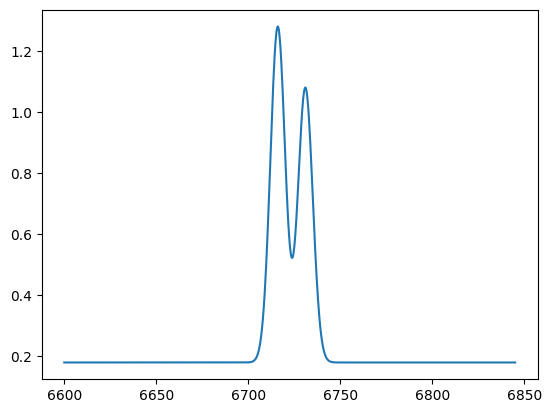

In [ ]:
line = np.linspace(6600.,6845., 1000)

plt.plot(
    line,
    doublet(line, 1.1, 0.9, 6716.,6731., 4., 0.18)
    )

Text(0, 0.5, 'Flux [erg/s/cm^2/Angstrom]')

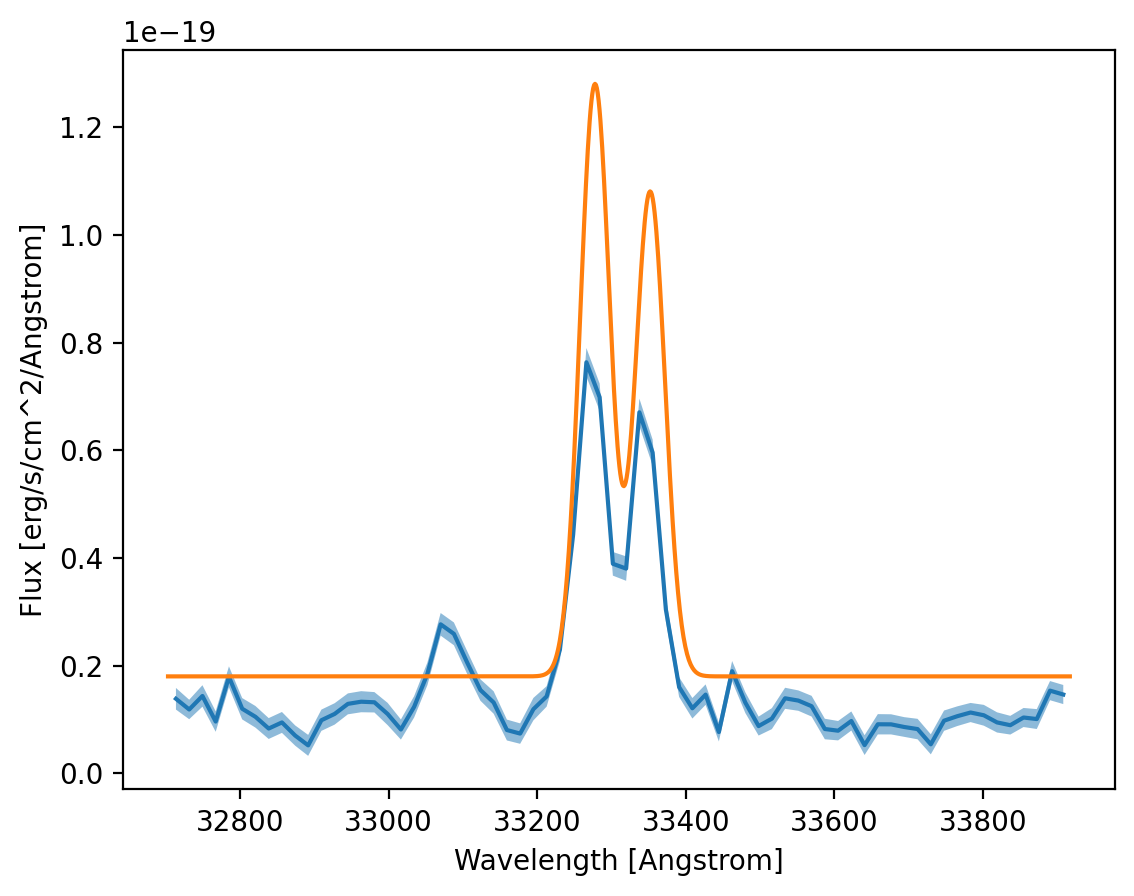

In [ ]:
# Plotting the [SII] doublet
plt.figure(dpi=200)
sii_mask = (spectrum[:,0]>6600.*(1+z_spec)) & (spectrum[:,0]<6845.*(1+z_spec))

plt.plot(spectrum[:,0][sii_mask],spectrum[:,1][sii_mask])
plt.fill_between(spectrum[:,0][sii_mask],spectrum[:,1][sii_mask]-spectrum[:,2][sii_mask],spectrum[:,1][sii_mask]+spectrum[:,2][sii_mask], alpha=0.5)

line = np.linspace(6600.*(1+z_spec),6845.*(1+z_spec), 1000)

plt.plot(
    line,
    doublet(line, 1.1e-19, 0.9e-19, 6716.*(1+z_spec),6731.*(1+z_spec), 20., 0.18e-19)
    )

plt.xlabel('Wavelength [Angstrom]')
plt.ylabel('Flux [erg/s/cm^2/Angstrom]')

To find the optimal parameters we use the scipy least_squares function. This function is designed to find the optimum parameters where the residuals^2 are minimised (hence the name "least squares").

Some documentation for the function can be found here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html


In [ ]:
# Find the best fit parameters by minimising the residuals^2, so minimising (model-data)^2
initial = np.array([1., 1., 30, 0.2, z_spec]) # your initial guess
result = least_squares(residuals, initial, args=(spectrum[:,0][sii_mask],1e19*spectrum[:,1][sii_mask])) # Finding the best parameters

In [ ]:
best_params = fit_sii_doublet(spectrum[:,0],spectrum[:,1], z_spec)

In [ ]:
def fit_doublet():
  return best_params

In [ ]:
# Show best fit parameters
result.x

array([ 0.68177897,  0.56168536, 19.83613756,  0.11755417,  3.95403319])

Text(0, 0.5, 'Flux [erg/s/cm^2/Angstrom]')

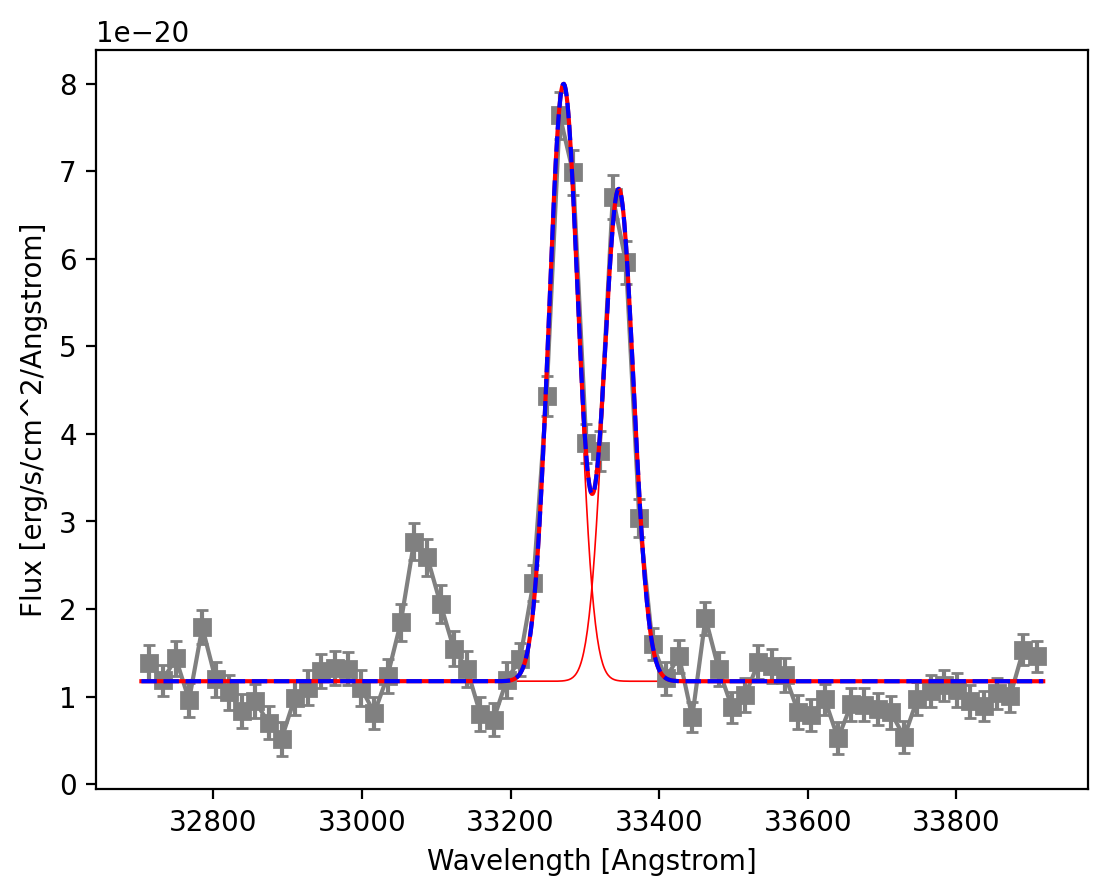

In [ ]:
# Plotting the [SII] doublet
plt.figure(dpi=200)
sii_mask = (spectrum[:,0]>6600.*(1+z_spec)) & (spectrum[:,0]<6845.*(1+z_spec))

plt.errorbar(spectrum[:,0][sii_mask],spectrum[:,1][sii_mask], yerr=spectrum[:,2][sii_mask], capsize=2, marker='s', color='grey')

line = np.linspace(6600.*(1+z_spec),6845.*(1+z_spec), 1000)

# plotting the fit
plt.plot(
    line,
    doublet(line, result.x[0]*1e-19, result.x[1]*1e-19, 6716.*(1+result.x[4]),6731.*(1+result.x[4]), result.x[2], result.x[3]*1e-19),
    zorder=10,
    color='r'
    )

# plotting the fit
plt.plot(
    line,
    doublet(line, best_params[0]*1e-19, best_params[1]*1e-19, 6716.*(1+best_params[4]),6731.*(1+best_params[4]), best_params[2], best_params[3]*1e-19),
    zorder=10,
    color='b', linestyle='--'
    )

# Plotting the individual gaussians
plt.plot(
    line,
    gaussian(line, result.x[0]*1e-19, 6716.*(1+result.x[4]), result.x[2]) + result.x[3]*1e-19,
    color='r', linewidth=0.6
    )

plt.plot(
    line,
    gaussian(line, result.x[1]*1e-19, 6731.*(1+result.x[4]), result.x[2]) + result.x[3]*1e-19,
    color='r', linewidth=0.6
    )


plt.xlabel('Wavelength [Angstrom]')
plt.ylabel('Flux [erg/s/cm^2/Angstrom]')

In [ ]:
wave = spectrum[:,0]
flux = spectrum[:,1]
error = spectrum[:,2]

nmonte=50
for _ in range(nmonte):
  _flux = flux + np.random.normal(size=len(wave), scale=error)
  print(fit_sii_doublet(wave, _flux, z_spec))


[ 0.67423145  0.55594161 20.25472062  0.11589403  3.95394179]
[ 0.66171831  0.52301318 20.06062267  0.11960261  3.95413379]
[ 0.67231149  0.57121021 19.98850241  0.11302765  3.95383266]
[ 0.6911809   0.5766555  18.72493025  0.12097594  3.95413176]
[ 0.66749193  0.55373254 20.7549544   0.11675357  3.95409791]
[ 0.71611323  0.56901064 19.32732819  0.1217545   3.95394262]
[ 0.65636191  0.54950914 19.94435817  0.11935393  3.95387504]
[ 0.69115905  0.60444498 19.45439357  0.1145227   3.95412784]
[ 0.68340322  0.57535211 19.39362552  0.12004467  3.9539909 ]
[ 0.64738051  0.52440307 20.09564302  0.11869706  3.95404942]
[ 0.70237077  0.60158355 18.99587505  0.11508792  3.95391922]
[ 0.68646067  0.56911716 19.40492199  0.1187196   3.95398264]
[ 0.68804583  0.56317521 19.70889305  0.11593904  3.95405847]
[ 0.68946263  0.57023947 20.23935111  0.11587508  3.9540356 ]
[ 0.7020721   0.57545798 19.47030811  0.11709236  3.95389437]
[ 0.6916158   0.57383239 20.10099195  0.11345997  3.9540042 ]
[ 0.6832

### Combining catalogs

At the top of the script where tou do your imports you will need to change the line `from astropy.table import Table` to `from astropy.table import Table, join`. This now additionally imports the `join` function that allows you to join tables.

In [21]:
bagpipes = Table.read('./drive/MyDrive/MPhysProject2025/data/bpass.continuum.delayed.with-miri.fits')
# Fix the issue with the different class of the targetid
bagpipes['targetid'] = [int(idx) for idx in bagpipes["#ID"]]

In [14]:
# Match bagpipes to the catalog table using the join function.
bagpipes_matched = join(catalog[['targetid']], bagpipes, keys='targetid', join_type='left')

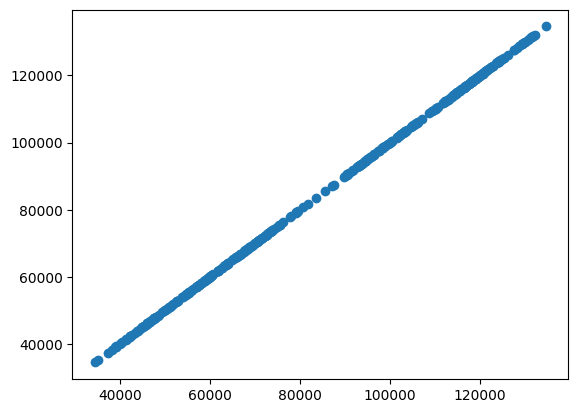

In [19]:
# Plot the targetids using both catalogs to check that they are matched correctly. This all looks OK!
plt.scatter(catalog['targetid'], bagpipes_matched['targetid'])

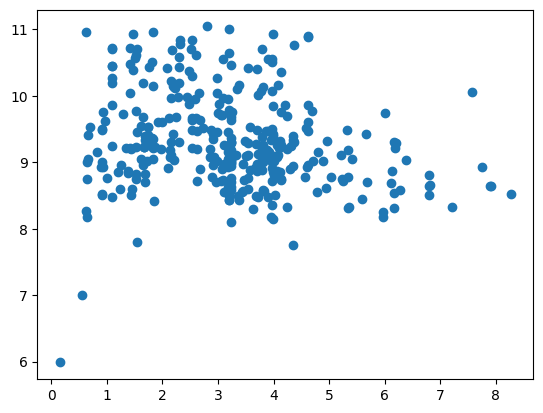

In [20]:
# Now you can plot the content of the different tables together.
plt.scatter(catalog['z_excels_v1'], bagpipes_matched['stellar_mass_50'])